# TME ML Non supervisé

In [3]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt

# K-Means et Geographical clustering

## 1- Data preparation

<div class="alert alert-block alert-info">
For this section, we will use the points of interest (POI) data of Paris. The objective is to spatially characterize the urban space of Paris based on the POIs present in a region. Clustering the regions thus highlights similar areas and the reasons for their similarity (by analyzing the prototype of each cluster).

The following lines allow you to draw the districts of Paris from the <code>districts-paris.csv</code> file and to load the POIs (from the <code>poi-paris.csv</code> file).
</div>


In [4]:
table_poi = pd.read_csv('data/poi-paris.csv')
districts=pd.read_csv('data/districts-paris.csv', sep = ',')
districts['bounds'] = districts['bounds'].apply(eval)
#  Draw the districts
def draw_districts():
    for x in districts['bounds']:
        plt.plot([c[0] for c in x], [c[1] for c in x], color = 'black')

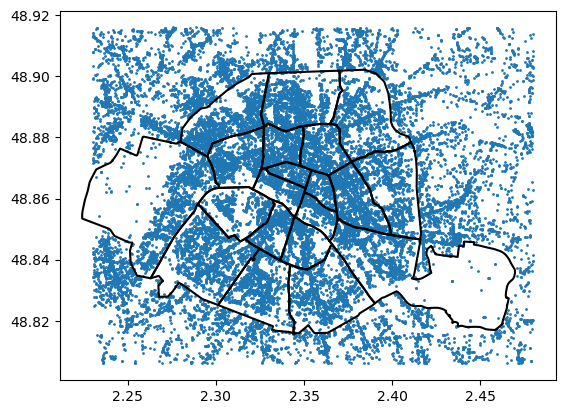

In [5]:
plt.scatter(table_poi["longitude"],table_poi['latitude'],s=1)
draw_districts()

### 2 - Discrétisation manuelle de l'espace

<div class="alert alert-block alert-info">
We cannot use the natural discretization of the districts because it is too coarse and groups together sub-regions of very different types. One initial approach to obtain interesting sub-regions in Paris is to manually discretize using a grid. We will assume a regular grid of size $N$.

Thus, for a GPS coordinate $(long,lat)$, we need to know which grid cell $(i,j)$ it corresponds to. For a grid of size $N \times N$, the formula is as follows: 
$i=\lfloor N*\frac{(longitude-lomin)}{(lomax-lomin)}\rfloor$ 
and 
$j = \lfloor N*\frac{(latitude - lamin)}{(lamax-lamin)} \rfloor$,
with $\lfloor x\rfloor$ denoting the integer part of $x$, $lamin,lamax$ the minimum and maximum latitudes, and $lomin,lomax$ the minimum and maximum longitudes.

Each grid cell will be described by the distribution of the types of POIs present in the corresponding area. There are 12 types of POIs, so each cell is described by a 12-dimensional vector, where each dimension indicates the probability of the type associated with that dimension in the region.
    
Compute the description associated with each cell. 

Run a k-means algorithm on it (using <code>KMeans</code> from scikit-learn, where <code>n_clusters</code> sets the number of clusters; the <code>fit()</code> method performs the clustering; the <code>predict()</code> method obtains the cluster associated with each example; and the <code>fit_predict()</code> method does both at the same time).

Also, visualize the centroids of the clusters. Vary the number of clusters and compare the results.

The following code graphically represents the computed clustering (with <code>get_clust(i,j)</code> returning the cluster number associated with cell $(i,j)$) and plots the centroids (from a KMeans stored in the variable <code>km</code>).
</div>


In [43]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=12)

# res = kmeans.fit_predict(table_poi[["latitude","longitude"]])

km.fit(table_poi[["latitude","longitude"]])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",12
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [21]:
lomin, lomax = table_poi["longitude"].min(), table_poi["longitude"].max()
lamin, lamax = table_poi["latitude"].min(), table_poi["latitude"].max()
N=10

In [37]:
pd.DataFrame([{"longitude": 0, 
              "latitude": 0}])

,longitude,latitude
0,0,0


In [56]:
def get_clust(i,j):
    x = lomin + (lomax - lomin) * i / N
    y = lamin + (lamax - lamin) * j / N
    cluster = km.predict(pd.DataFrame([{ "latitude": x, "longitude": y}]))[0]
    print(x,y,cluster)
    return cluster
    

In [47]:
tab20 = plt.get_cmap("tab20")

2.2300034 48.80602630000001 9
2.2300034 48.81702243000001 9
2.2300034 48.82801856000001 9
2.2300034 48.83901469000001 9
2.2300034 48.85001082000001 9
2.2300034 48.861006950000004 9
2.2300034 48.872003080000006 9
2.2300034 48.88299921000001 9
2.2300034 48.893995340000004 9
2.2300034 48.90499147 9
2.2550021300000003 48.80602630000001 9
2.2550021300000003 48.81702243000001 9
2.2550021300000003 48.82801856000001 9
2.2550021300000003 48.83901469000001 9
2.2550021300000003 48.85001082000001 9
2.2550021300000003 48.861006950000004 9
2.2550021300000003 48.872003080000006 9
2.2550021300000003 48.88299921000001 9
2.2550021300000003 48.893995340000004 9
2.2550021300000003 48.90499147 9
2.2800008600000004 48.80602630000001 9
2.2800008600000004 48.81702243000001 9
2.2800008600000004 48.82801856000001 9
2.2800008600000004 48.83901469000001 9
2.2800008600000004 48.85001082000001 9
2.2800008600000004 48.861006950000004 9
2.2800008600000004 48.872003080000006 9
2.2800008600000004 48.88299921000001 9
2.

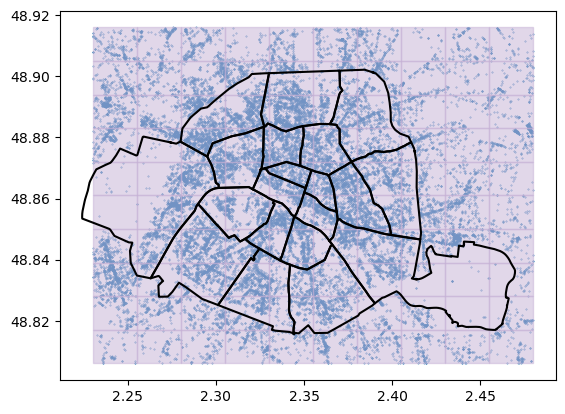

In [57]:
from matplotlib.patches import Rectangle
tab20 = plt.get_cmap("tab20")
_ = plt.scatter(table_poi["longitude"],table_poi['latitude'],s=0.1)
draw_districts()

for i in range(N):
    for j in range(N):
        x = lomin + (lomax - lomin) * i / N
        y = lamin + (lamax - lamin) * j / N
        c = tab20.colors[get_clust(i,j)]
        _ = plt.gca().add_patch(Rectangle((x, y), (lomax - lomin) / N, (lamax - lamin) / N, color = c, alpha = 0.5))


In [ ]:
fig, axs = plt.subplots(len(km.cluster_centers_)//2, 2, sharey=True,sharex=True)
for i,k in enumerate(km.cluster_centers_):
    axs.flatten()[i].bar(range(len(k)),k,color=tab20.colors[i])
    axs.flatten()[i].set_xticks(range(len(k)))
    axs.flatten()[i].set_xticklabels(types,rotation="vertical")

<div class="alert alert-block alert-info">
The model's elbow score corresponds to the model's <em>inertia_</em> attribute. Plot the elbow curve as a function of the number of clusters. What is the optimal number of clusters according to this curve?
</div>


## 3 -  K-Means pour la discrétisation automatique de l'espace

<div class="alert alert-block alert-info">
To obtain more relevant clusters, the discretization of space must be done in a less naive way. One idea is also to use the $K$-means algorithm for this, by clustering the GPS coordinates of the POIs (which is also called a <em>quantization</em>). 
</br>
Calculate this spatial clustering and assign each POI a spatial cluster number (note: a grid of size $10\times 10$ is "equivalent" to having 100 clusters).

Graphically represent the clusters thus obtained using the following lines of code (<code>get_cluster_spatial(i)</code> returns the cluster of the $i$-th POI, and the KMeans model is stored in the variable <code>km_spatial</code>).

Perform clustering on this new discretization and compare your results.

Observe the correlation between the types in the initial data. Can you propose a method to improve the results?
</div>


In [ ]:
draw_districts()
plt.scatter(table_poi['longitude'],table_poi['latitude'],color = [tab20.colors[get_cluster_spatial(i) % 20] for i in range(len(table_poi))], s = 0.5)
for i in range(K_GEO):
    plt.plot(km_spatial.cluster_centers_[i, 0], km_spatial.cluster_centers_[i, 1], marker = "*", color = "black", markersize = 5)